In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import random
import math
import time
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


In [9]:
!wget -q https://download.pytorch.org/tutorial/data.zip
!unzip -q -o data.zip
!head -5 data/eng-fra.txt

Go.	Va !
Run!	Cours !
Run!	Courez !
Wow!	Ça alors !
Fire!	Au feu !


In [10]:
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def normalize_string(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

with open('data/eng-fra.txt', encoding='utf-8') as f:
    lines = f.read().strip().split('\n')

pairs = [[normalize_string(s) for s in line.split('\t')] for line in lines]

# On garde les phrases courtes pour accélérer l'entraînement
MAX_LENGTH = 10
pairs = [p for p in pairs if len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH]

print(f"Nombre de paires conservées : {len(pairs)}")
print("Exemple :", pairs[0])

Nombre de paires conservées : 95204
Exemple : ['go .', 'va !']


In [11]:
SOS_token, EOS_token, PAD_token = 0, 1, 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "PAD": 2}
        self.index2word = {0: "SOS", 1: "EOS", 2: "PAD"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            if word not in self.word2index:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1

eng, fra = Lang('eng'), Lang('fra')
for p in pairs:
    eng.add_sentence(p[0])
    fra.add_sentence(p[1])

print(f"Vocabulaire anglais : {eng.n_words} mots")
print(f"Vocabulaire français : {fra.n_words} mots")

Vocabulaire anglais : 10026 mots
Vocabulaire français : 16815 mots


In [12]:
def sentence_to_indices(lang, sentence):
    return [lang.word2index[w] for w in sentence.split(' ')] + [EOS_token]

class TranslationDataset(Dataset):
    def __init__(self, pairs, eng, fra, max_len=12):
        self.pairs = pairs
        self.eng = eng
        self.fra = fra
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng_s, fra_s = self.pairs[idx]
        e = sentence_to_indices(self.eng, eng_s)
        f = sentence_to_indices(self.fra, fra_s)
        e = e[:self.max_len] + [PAD_token]*(self.max_len-len(e))
        f = f[:self.max_len] + [PAD_token]*(self.max_len-len(f))
        return torch.tensor(e), torch.tensor(f)

dataset = TranslationDataset(pairs, eng, fra)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

x, y = next(iter(train_loader))
print("Batch source :", x.shape, "| Batch cible :", y.shape)

Batch source : torch.Size([64, 12]) | Batch cible : torch.Size([64, 12])


In [13]:
# Un modèle de langage apprend :
# P(w1, w2, ..., wT) = Π_{t=1}^{T} P(wt | w1, ..., w(t-1))   ← règle de chaîne
#
# La perplexité mesure la "surprise" du modèle face à une séquence :
# Perplexité = exp(Loss moyenne en entropie croisée)
# → Plus elle est basse, plus le modèle prédit bien la suite.

def perplexity_from_loss(loss):
    return math.exp(loss)

print("Loss=2.0 → Perplexité =", round(perplexity_from_loss(2.0), 2))
print("Loss=0.5 → Perplexité =", round(perplexity_from_loss(0.5), 2))

Loss=2.0 → Perplexité = 7.39
Loss=0.5 → Perplexité = 1.65


In [14]:
class LMDataset(Dataset):
    def __init__(self, sentences, lang, max_len=12):
        self.data = []
        for s in sentences:
            idx = sentence_to_indices(lang, s)
            idx = idx[:max_len] + [PAD_token]*(max_len-len(idx))
            self.data.append(idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        seq = torch.tensor(self.data[i])
        return seq[:-1], seq[1:]   # input décalé / target décalé d'un mot

eng_sentences = [p[0] for p in pairs]
lm_loader = DataLoader(LMDataset(eng_sentences, eng), batch_size=64, shuffle=True)

In [15]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256, rnn_type='RNN'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        return self.fc(out)

In [16]:
def train_lm(rnn_type, clip_grad=True, num_epochs=5):
    model = LanguageModel(eng.n_words, rnn_type=rnn_type).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

    losses = []
    start = time.time()
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for x, y in lm_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.reshape(-1, eng.n_words), y.reshape(-1))
            loss.backward()
            if clip_grad:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(lm_loader)
        losses.append(avg_loss)
        print(f"[{rnn_type}] Époque {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Perplexité: {math.exp(avg_loss):.2f}")
    return model, losses, time.time() - start

results = {}
for rnn_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\n=== {rnn_type} ===")
    _, losses, duration = train_lm(rnn_type, clip_grad=True, num_epochs=5)
    results[rnn_type] = {'losses': losses, 'duration': duration}


=== RNN ===
[RNN] Époque 1/5 | Loss: 3.6748 | Perplexité: 39.44
[RNN] Époque 2/5 | Loss: 2.9649 | Perplexité: 19.39
[RNN] Époque 3/5 | Loss: 2.6933 | Perplexité: 14.78
[RNN] Époque 4/5 | Loss: 2.5134 | Perplexité: 12.35
[RNN] Époque 5/5 | Loss: 2.3796 | Perplexité: 10.80

=== LSTM ===
[LSTM] Époque 1/5 | Loss: 3.7643 | Perplexité: 43.13
[LSTM] Époque 2/5 | Loss: 2.9877 | Perplexité: 19.84
[LSTM] Époque 3/5 | Loss: 2.6735 | Perplexité: 14.49
[LSTM] Époque 4/5 | Loss: 2.4540 | Perplexité: 11.63
[LSTM] Époque 5/5 | Loss: 2.2881 | Perplexité: 9.86

=== GRU ===
[GRU] Époque 1/5 | Loss: 3.6366 | Perplexité: 37.96
[GRU] Époque 2/5 | Loss: 2.8706 | Perplexité: 17.65
[GRU] Époque 3/5 | Loss: 2.5703 | Perplexité: 13.07
[GRU] Époque 4/5 | Loss: 2.3668 | Perplexité: 10.66
[GRU] Époque 5/5 | Loss: 2.2158 | Perplexité: 9.17


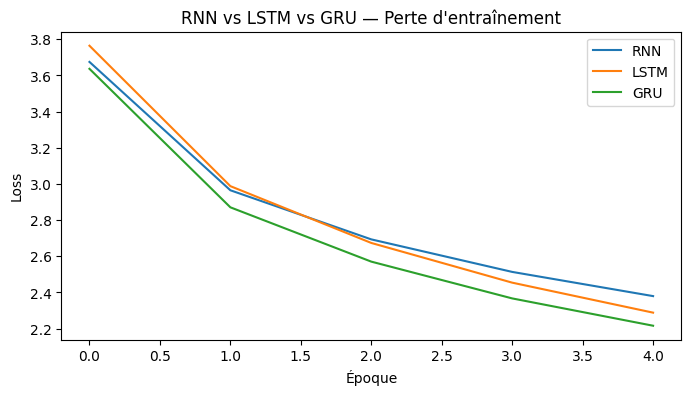

=== Coût de calcul (temps d'entraînement) ===
RNN : 50.4 s
LSTM : 56.4 s
GRU : 56.3 s
[RNN] Époque 1/5 | Loss: 3.6682 | Perplexité: 39.18
[RNN] Époque 2/5 | Loss: 2.9595 | Perplexité: 19.29
[RNN] Époque 3/5 | Loss: 2.6904 | Perplexité: 14.74
[RNN] Époque 4/5 | Loss: 2.5103 | Perplexité: 12.31
[RNN] Époque 5/5 | Loss: 2.3773 | Perplexité: 10.78
[RNN] Époque 1/5 | Loss: 3.6632 | Perplexité: 38.99
[RNN] Époque 2/5 | Loss: 2.9617 | Perplexité: 19.33
[RNN] Époque 3/5 | Loss: 2.6919 | Perplexité: 14.76
[RNN] Époque 4/5 | Loss: 2.5121 | Perplexité: 12.33
[RNN] Époque 5/5 | Loss: 2.3788 | Perplexité: 10.79


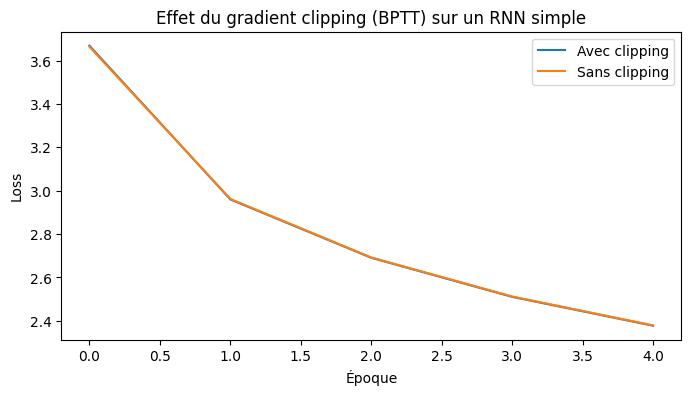

In [17]:
plt.figure(figsize=(8,4))
for rnn_type in results:
    plt.plot(results[rnn_type]['losses'], label=rnn_type)
plt.title("RNN vs LSTM vs GRU — Perte d'entraînement")
plt.xlabel("Époque"); plt.ylabel("Loss"); plt.legend()
plt.show()

print("=== Coût de calcul (temps d'entraînement) ===")
for rnn_type in results:
    print(f"{rnn_type} : {results[rnn_type]['duration']:.1f} s")

# Effet du gradient clipping sur le RNN simple (le plus instable)
_, losses_clip, _ = train_lm('RNN', clip_grad=True, num_epochs=5)
_, losses_noclip, _ = train_lm('RNN', clip_grad=False, num_epochs=5)

plt.figure(figsize=(8,4))
plt.plot(losses_clip, label='Avec clipping')
plt.plot(losses_noclip, label='Sans clipping')
plt.title("Effet du gradient clipping (BPTT) sur un RNN simple")
plt.xlabel("Époque"); plt.ylabel("Loss"); plt.legend()
plt.show()

In [18]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, hidden = self.gru(emb)
        return outputs, hidden

In [19]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        emb = self.embedding(x)
        output, hidden = self.gru(emb, hidden)
        return self.fc(output), hidden

In [20]:
encoder = Encoder(eng.n_words).to(device)
decoder = Decoder(fra.n_words).to(device)
enc_opt = torch.optim.Adam(encoder.parameters(), lr=0.001)
dec_opt = torch.optim.Adam(decoder.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

teacher_forcing_ratio = 0.5
num_epochs = 10
seq2seq_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    encoder.train()
    decoder.train()

    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        batch_size = src.size(0)
        max_tgt_len = tgt.size(1)

        enc_opt.zero_grad()
        dec_opt.zero_grad()

        # Initialisation du décodeur avec l'état caché final de l'encodeur
        _, hidden = encoder(src)
        decoder_input = torch.full((batch_size, 1), SOS_token, device=device)

        # Tenseur global pour stocker toutes les prédictions du lot
        all_decoder_outputs = torch.zeros(batch_size, max_tgt_len, fra.n_words).to(device)
        use_tf = random.random() < teacher_forcing_ratio

        for t in range(max_tgt_len):
            output, hidden = decoder(decoder_input, hidden)
            all_decoder_outputs[:, t, :] = output.squeeze(1)

            # Choix de l'entrée suivante (Teacher Forcing ou prédiction)
            decoder_input = tgt[:, t].unsqueeze(1) if use_tf else output.argmax(2)

        # Calcul global de la perte sur tout le lot (évite le bug des NaN lié aux PAD)
        loss = criterion(all_decoder_outputs.reshape(-1, fra.n_words), tgt.reshape(-1))
        loss.backward()

        # Écrêtage des gradients (Gradient Clipping) pour forcer la convergence
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=5.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)

        enc_opt.step()
        dec_opt.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    seq2seq_losses.append(avg_loss)
    print(f"Époque {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Perplexité: {math.exp(avg_loss):.2f}")

Époque 1/10 | Loss: 3.9119 | Perplexité: 49.99
Époque 2/10 | Loss: 2.7411 | Perplexité: 15.50
Époque 3/10 | Loss: 2.2118 | Perplexité: 9.13
Époque 4/10 | Loss: 1.8728 | Perplexité: 6.51
Époque 5/10 | Loss: 1.6389 | Perplexité: 5.15
Époque 6/10 | Loss: 1.4595 | Perplexité: 4.30
Époque 7/10 | Loss: 1.3448 | Perplexité: 3.84
Époque 8/10 | Loss: 1.2388 | Perplexité: 3.45
Époque 9/10 | Loss: 1.1426 | Perplexité: 3.13
Époque 10/10 | Loss: 1.0630 | Perplexité: 2.89


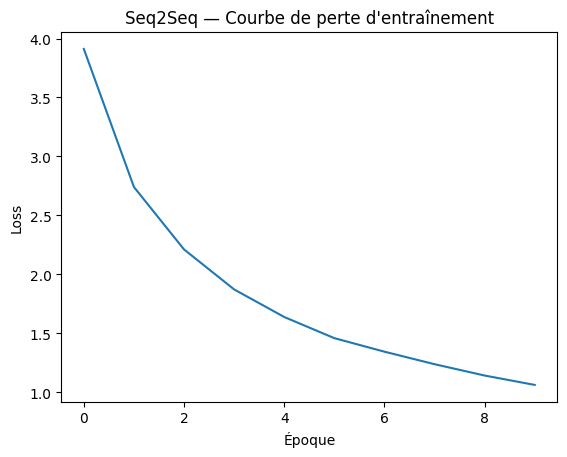

In [21]:
plt.plot(seq2seq_losses)
plt.title("Seq2Seq — Courbe de perte d'entraînement")
plt.xlabel("Époque"); plt.ylabel("Loss")
plt.show()

In [22]:
def greedy_decode(sentence, max_length=12):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        idx = sentence_to_indices(eng, normalize_string(sentence))
        idx = idx[:max_length] + [PAD_token]*(max_length-len(idx))
        src = torch.tensor(idx).unsqueeze(0).to(device)

        _, hidden = encoder(src)
        decoder_input = torch.tensor([[SOS_token]], device=device)
        words = []

        for _ in range(max_length):
            output, hidden = decoder(decoder_input, hidden)
            top_idx = output.argmax(2).item()
            if top_idx == EOS_token:
                break
            words.append(fra.index2word[top_idx])
            decoder_input = torch.tensor([[top_idx]], device=device)
    return ' '.join(words)

for s in [pairs[i][0] for i in range(5)]:
    print(f"EN : {s}")
    print(f"FR (prédit) : {greedy_decode(s)}\n")

EN : go .
FR (prédit) : va !

EN : run !
FR (prédit) : courez !

EN : run !
FR (prédit) : courez !

EN : wow !
FR (prédit) : alors !

EN : fire !
FR (prédit) : depeche ! feu !



In [23]:
encoder = Encoder(eng.n_words).to(device)
decoder = Decoder(fra.n_words).to(device)
enc_opt = torch.optim.Adam(encoder.parameters(), lr=0.001)
dec_opt = torch.optim.Adam(decoder.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

teacher_forcing_ratio = 0.5
num_epochs = 10
seq2seq_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        batch_size = src.size(0)
        enc_opt.zero_grad()
        dec_opt.zero_grad()

        _, hidden = encoder(src)
        decoder_input = torch.full((batch_size, 1), SOS_token, device=device)
        loss = torch.zeros(1, device=device)   # ← initialisation propre
        use_tf = random.random() < teacher_forcing_ratio

        for t in range(tgt.size(1)):
            output, hidden = decoder(decoder_input, hidden)
            loss += criterion(output.squeeze(1), tgt[:, t])
            decoder_input = (tgt[:, t].unsqueeze(1) if use_tf
                             else output.argmax(2).detach())  # ← .detach()

        loss = loss / tgt.size(1)
        loss.backward()

        # ← LES DEUX LIGNES CLÉS : clipping sur encoder ET decoder
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=5.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)

        enc_opt.step()
        dec_opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    seq2seq_losses.append(avg_loss)
    print(f"Époque {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Perplexité: {math.exp(avg_loss):.2f}")

Époque 1/10 | Loss: nan | Perplexité: nan
Époque 2/10 | Loss: nan | Perplexité: nan
Époque 3/10 | Loss: nan | Perplexité: nan
Époque 4/10 | Loss: nan | Perplexité: nan
Époque 5/10 | Loss: nan | Perplexité: nan
Époque 6/10 | Loss: nan | Perplexité: nan
Époque 7/10 | Loss: nan | Perplexité: nan
Époque 8/10 | Loss: nan | Perplexité: nan
Époque 9/10 | Loss: nan | Perplexité: nan
Époque 10/10 | Loss: nan | Perplexité: nan


In [24]:
def bleu_score_simple(reference, candidate, max_n=2):
    ref_tok, cand_tok = reference.split(), candidate.split()
    if not cand_tok:
        return 0.0
    precisions = []
    for n in range(1, max_n+1):
        ref_ngrams = Counter([tuple(ref_tok[i:i+n]) for i in range(len(ref_tok)-n+1)])
        cand_ngrams = Counter([tuple(cand_tok[i:i+n]) for i in range(len(cand_tok)-n+1)])
        overlap = sum((ref_ngrams & cand_ngrams).values())
        precisions.append(overlap / max(sum(cand_ngrams.values()), 1))
    geo_mean = np.prod(precisions) ** (1/len(precisions)) if all(precisions) else 0
    bp = min(1.0, math.exp(1 - len(ref_tok)/len(cand_tok)))
    return geo_mean * bp

scores = [bleu_score_simple(fra_s, greedy_decode(eng_s)) for eng_s, fra_s in pairs[:50]]
print(f"BLEU score moyen (50 exemples) : {np.mean(scores):.4f}")

BLEU score moyen (50 exemples) : 0.2696
